# Keyword Search Failure

In [64]:
# Creating basic keyword matching search.

documents = [
    "Cars are very fast.",
    "Dogs are loyal animals.",
    "Automobiles are used for transport."
]

query = "car"

for doc in documents:
    if query.lower() in doc.lower():
        print(doc)

Cars are very fast.


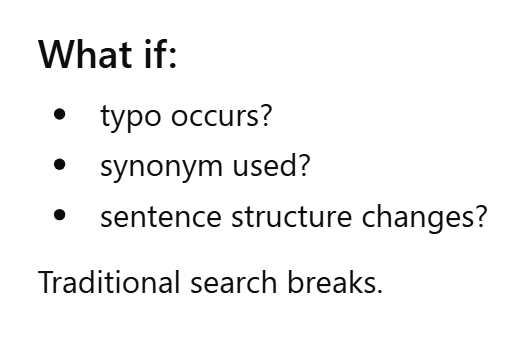

##### “Machines need meaning understanding, not word matching.”

# Generate Embeddings

### Converting text → vectors.

In [66]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2') # try alternate model and compare speed vector dimension,quality

# all-mpnet-base-v2, paraphrase-MiniLM-L6-v2
sentences = [
    "I love cricket",
    "I enjoy playing cricket",
    "Python is a programming language"
]

embeddings = model.encode(sentences)

print(embeddings.shape)

# similarity measurable
# distance calculable

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

(3, 768)


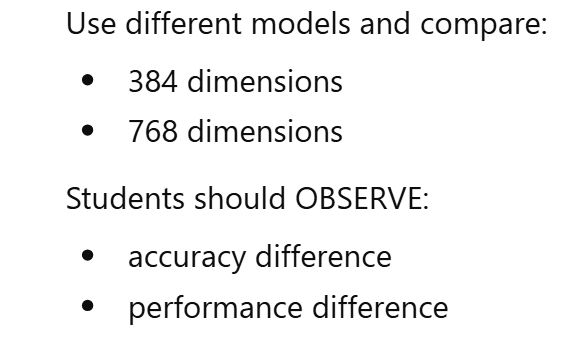

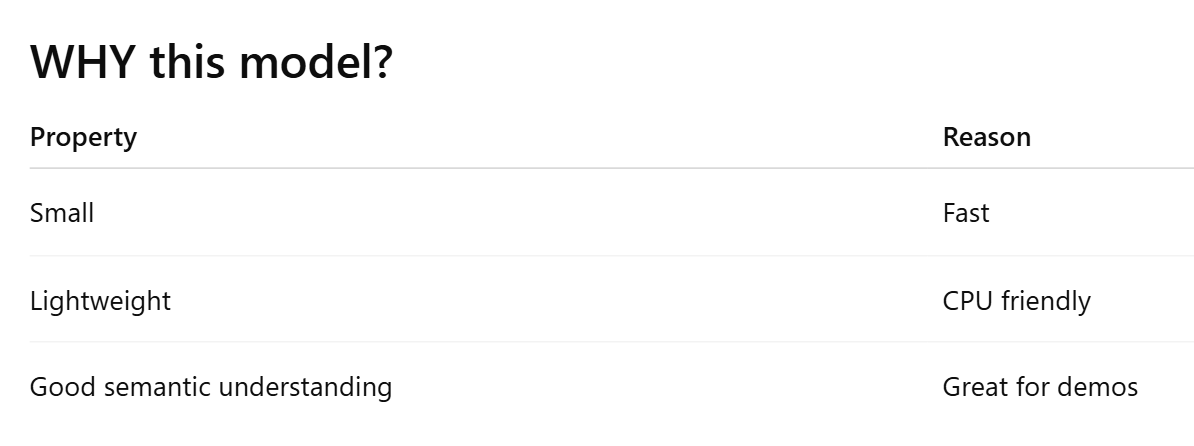

# Similarity Search

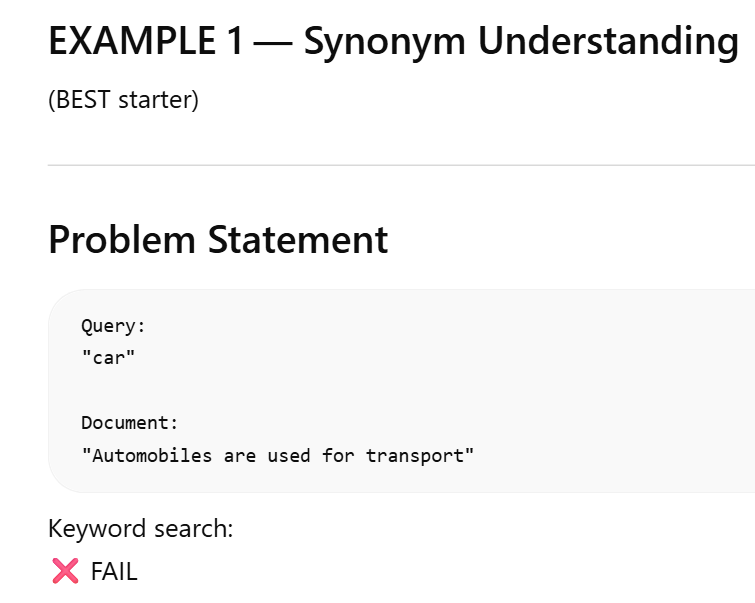

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

documents = [
    "Dogs are loyal pets",
    "Cars are used for transportation",
    "Cats love sleeping"
]

query = "automobile" # vechicle, transport ,kitten,puppy

doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, doc_embeddings)

print(similarities)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[[0.07507781 0.6599072  0.08040622]]


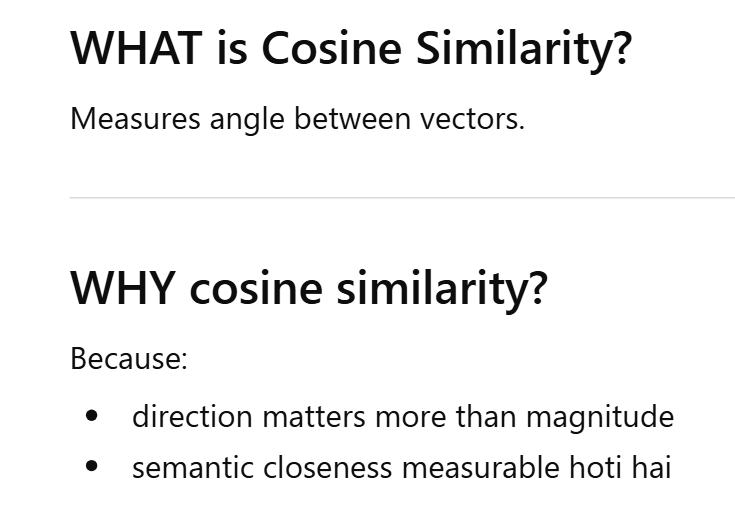

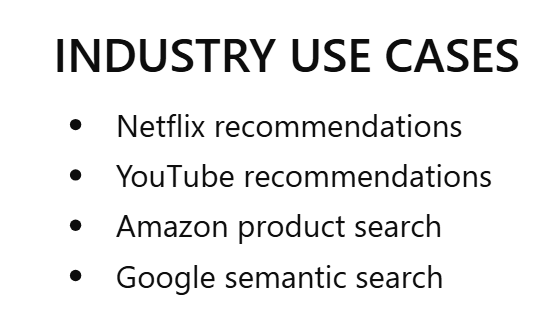

In [77]:
# Keyword Search Failure

documents = [
    "Automobiles are used for transport",
    "Dogs are loyal pets",
    "Python is used for AI"
]

query = "puppy"

for doc in documents:
    if query.lower() in doc.lower():
        print(doc)

In [78]:
# Semantic Search

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

documents = [
    "Automobiles are used for transport",
    "Dogs are loyal pets",
    "Python is used for AI",
    "Cats love sleeping"
]

query = "cars" # try cars, AI

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

for doc, score in zip(documents, scores):
    print(f"{doc} --> {score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Automobiles are used for transport --> 0.5922
Dogs are loyal pets --> 0.0846
Python is used for AI --> 0.1486
Cats love sleeping --> 0.1119


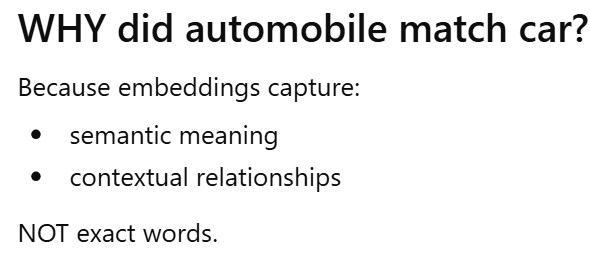

### Intent-Based Search

In [80]:
documents = [
    "Cold coffee available here",
    "Fresh pizza served daily",
    "Buy laptops at discount"
]


query = "I want something to drink" # Fresh,discount

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

for doc, score in zip(documents, scores):
    print(f"{doc} --> {score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Cold coffee available here --> 0.3965
Fresh pizza served daily --> 0.1494
Buy laptops at discount --> 0.0811


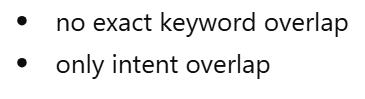

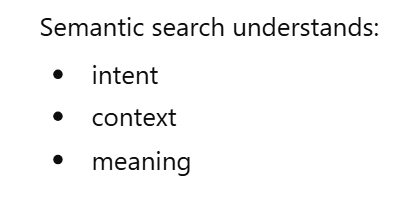

## Sentence-Level Similarity

In [81]:
sentences = [
    "I love playing cricket",
    "Cricket is my favorite sport",
    "I enjoy eating pizza"
]

query = "I like cricket" # Fresh,discount

model = SentenceTransformer('all-MiniLM-L6-v2')

   = model.encode(sentences)
query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

for doc, score in zip(sentences, scores):
    print(f"{doc} --> {score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

I love playing cricket --> 0.8649
Cricket is my favorite sport --> 0.8651
I enjoy eating pizza --> 0.3828


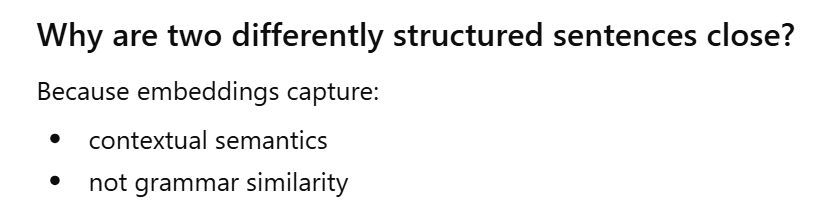

#### Add Ranking

In [84]:
ranked_results = sorted(
    zip(sentences, scores),
    key=lambda x: x[1],
    reverse=True
)

for rank, (sentence, score) in enumerate(ranked_results, start=1):
    print(rank, sentence, score)

1 Cricket is my favorite sport 0.86513174
2 I love playing cricket 0.86488307
3 I enjoy eating pizza 0.38284215


### Similarity Thresholding

In [87]:
threshold = 0.3 # 0.5,0.8

for doc, score in zip(documents, scores):
    if score > threshold:
        print(doc, score)

Cold coffee available here 0.86488307
Fresh pizza served daily 0.86513174
Buy laptops at discount 0.38284215


In [94]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

documents = [
    "Employees receive 20 annual paid leaves.",
    
    "Employees can work remotely twice a week.",
    
    "Health insurance covers employees and family members.",
    
    "Travel reimbursement is provided for business trips.",
    
    "The office cafeteria serves free lunch on Fridays.",
    
    "Employees must submit leave requests through the HR portal.",
    
    "Parking slots are allocated on a first-come-first-serve basis."
]

query = "Any idea about leaves?" # (1,,384)

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents) #(7,384)

query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

for doc, score in zip(documents, scores):
    print(f"{score:.4f} --> {doc}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

0.4210 --> Employees receive 20 annual paid leaves.
0.0156 --> Employees can work remotely twice a week.
0.0191 --> Health insurance covers employees and family members.
0.0189 --> Travel reimbursement is provided for business trips.
-0.0369 --> The office cafeteria serves free lunch on Fridays.
0.0239 --> Employees must submit leave requests through the HR portal.
-0.0165 --> Parking slots are allocated on a first-come-first-serve basis.


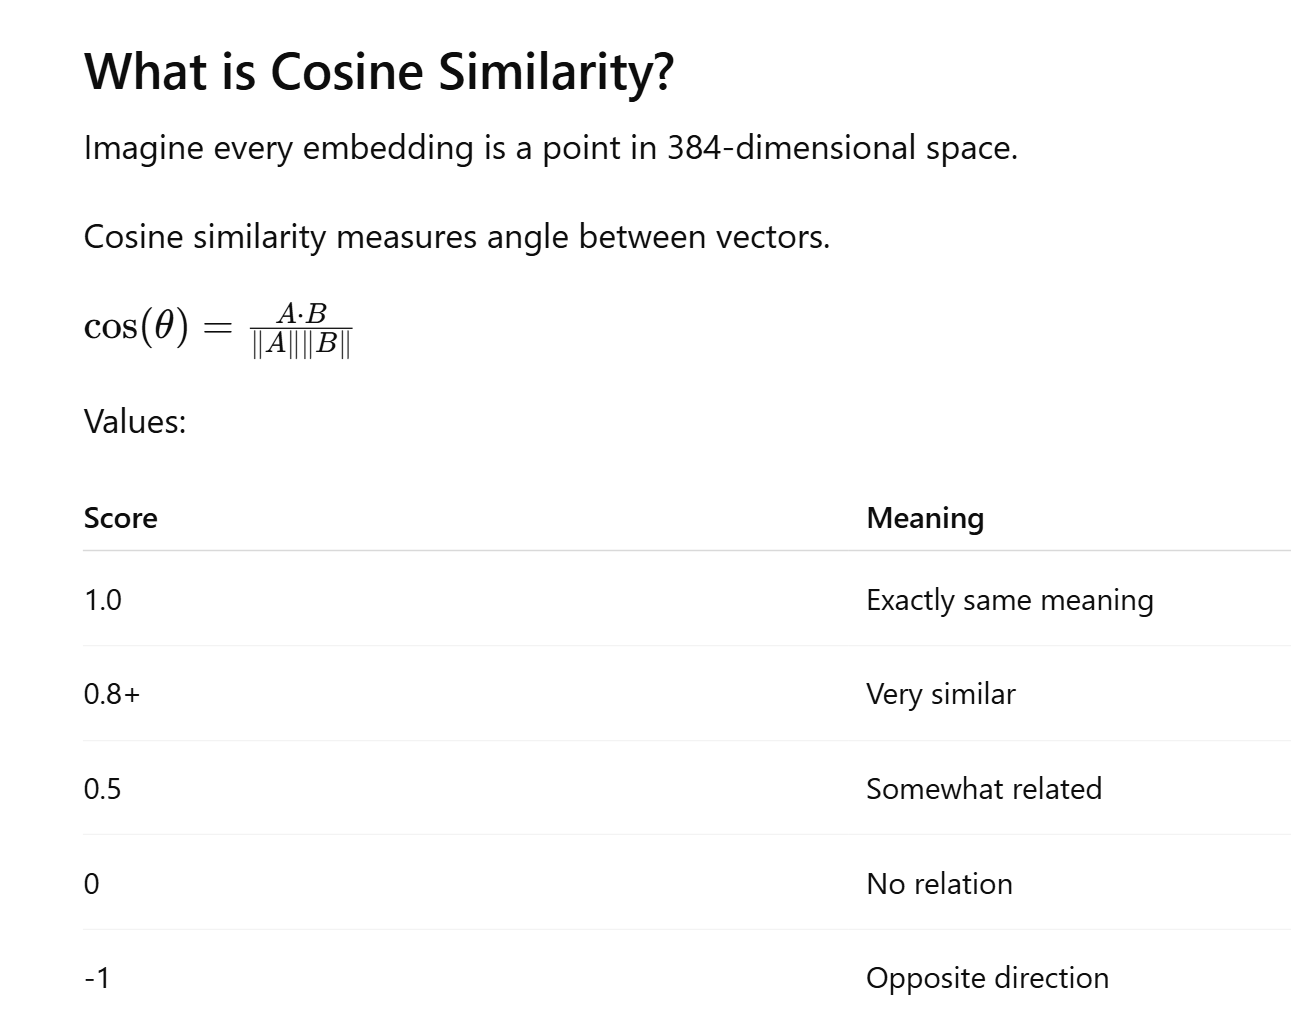

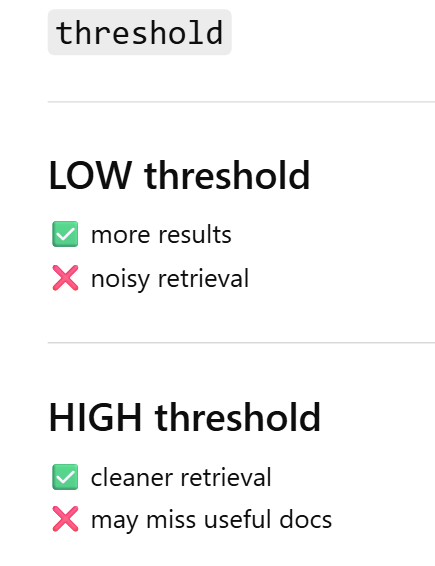

In [97]:
threshold = 0.4

for doc, score in zip(documents, scores):
    if score >= threshold:
        print(score, doc)

0.42095396 Employees receive 20 annual paid leaves.


In [98]:
top_k = 3

top_indices = np.argsort(scores)[::-1][:top_k]

for idx in top_indices:
    print(scores[idx], documents[idx])

0.42095396 Employees receive 20 annual paid leaves.
0.023854377 Employees must submit leave requests through the HR portal.
0.019072562 Health insurance covers employees and family members.


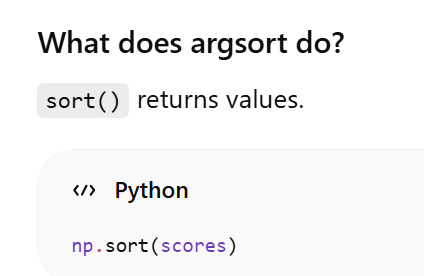

# Top-K Retrieval

In [21]:
top_k = 2

top_indices = np.argsort(scores)[::-1][:top_k]

for idx in top_indices:
    print(documents[idx], scores[idx])

Fresh pizza served daily 0.86513174
Cold coffee available here 0.86488307


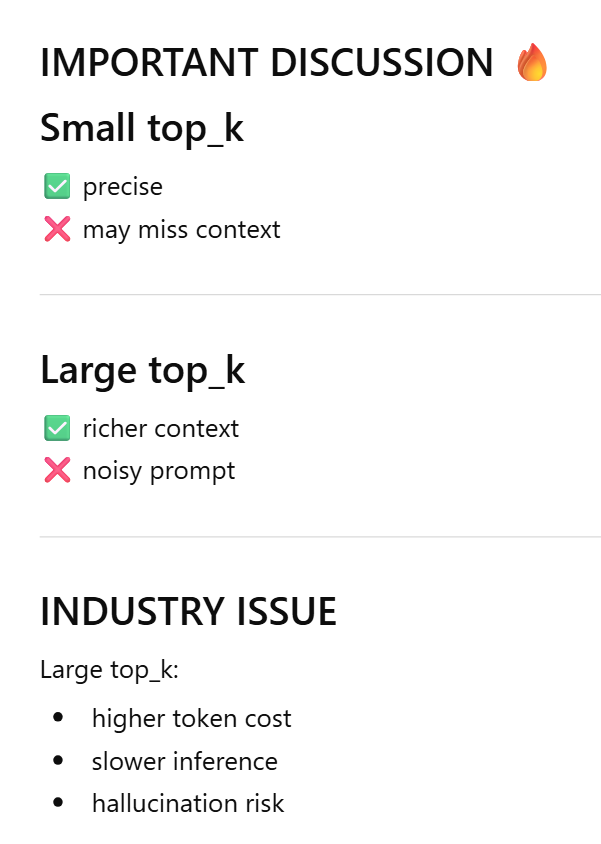

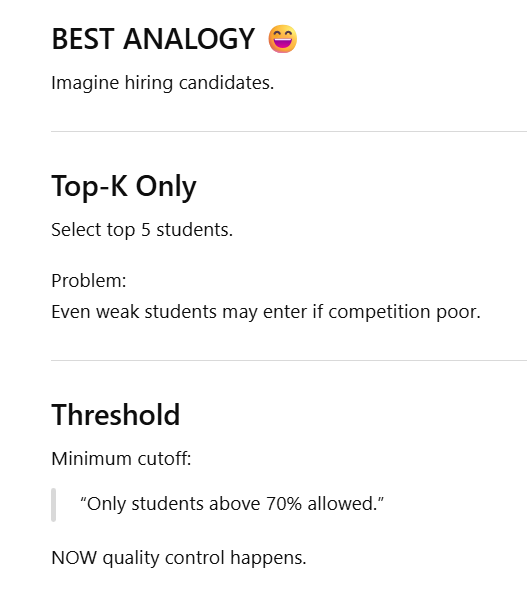

In [33]:
top_k = 2
threshold = 0.2

top_indices = np.argsort(scores)[::-1][:top_k]

filtered_results = []

for idx in top_indices:
    if scores[idx] >= threshold:
        filtered_results.append(
            (documents[idx], scores[idx])
        )

for doc, score in filtered_results:
    print(score, doc)

0.5625042 Employees must submit leave requests through the HR portal.
0.24418451 Employees receive 20 annual paid leaves.


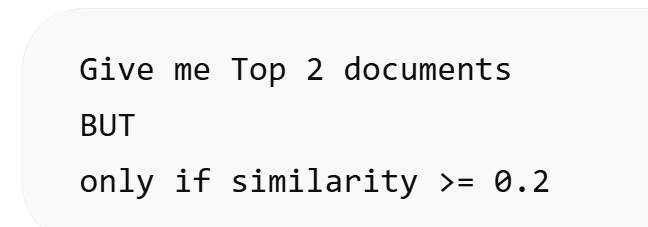

### Cross-Domain Similarity

In [100]:
documents = [
    "AI developer role available",
    "Chef needed in hotel",
    "Data scientist hiring"
]

In [101]:
query = "Machine learning engineer" # Fresh,discount

model = SentenceTransformer('all-MiniLM-L6-v2')

doc_embeddings = model.encode(documents)
query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

for doc, score in zip(documents, scores):
    print(f"{doc} --> {score:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

AI developer role available --> 0.4674
Chef needed in hotel --> 0.1096
Data scientist hiring --> 0.4917


#### Heatmap Visualization

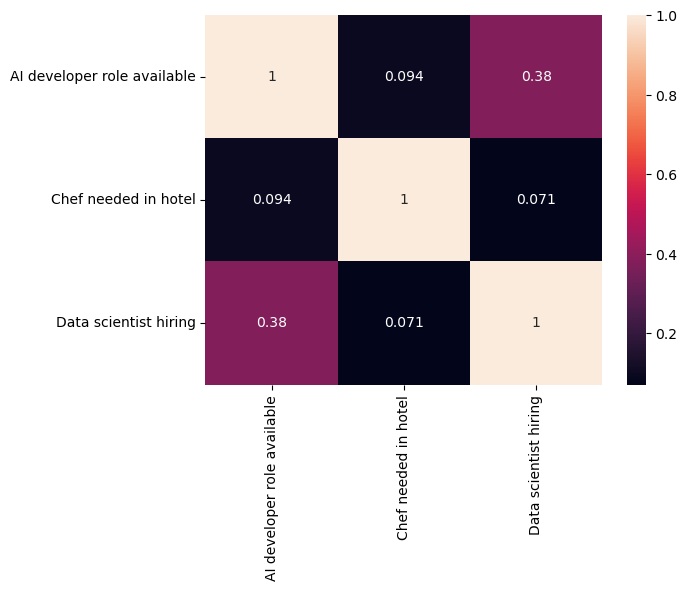

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

similarity_matrix = cosine_similarity(doc_embeddings)

sns.heatmap(
    similarity_matrix,
    annot=True,
    xticklabels=documents,
    yticklabels=documents,#cmap = 
)

plt.show()

# Chunking + Vector DB

### Chunking Experiment

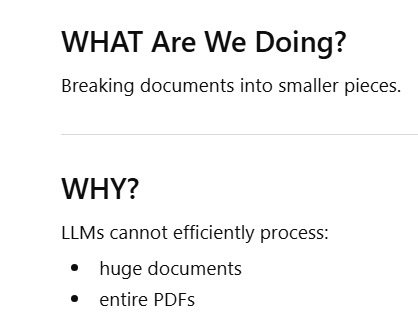

In [104]:
text = """
RAG is a technique used to improve LLM responses.
Embeddings convert text into vectors.
Semantic search finds meaning-based matches.
"""

chunk_size = 50

chunks = [
    text[i:i+chunk_size]
    for i in range(0, len(text), chunk_size)
]

print(chunks)

['\nRAG is a technique used to improve LLM responses.', '\nEmbeddings convert text into vectors.\nSemantic se', 'arch finds meaning-based matches.\n']


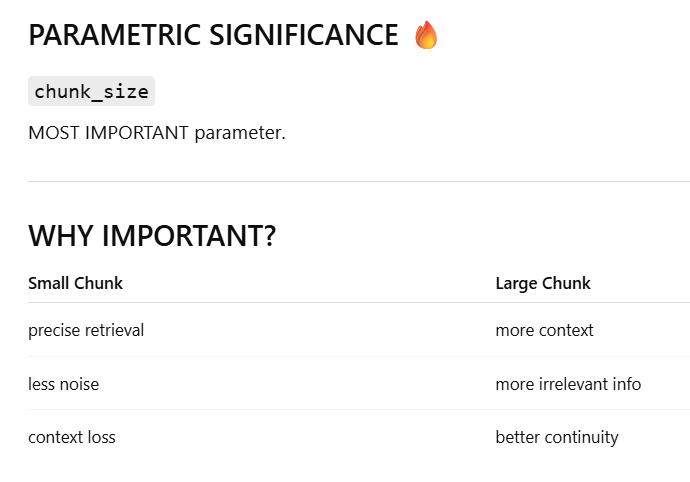

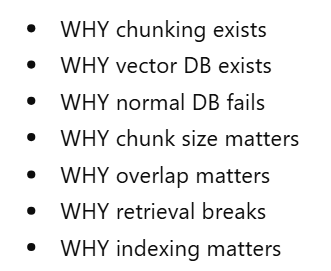

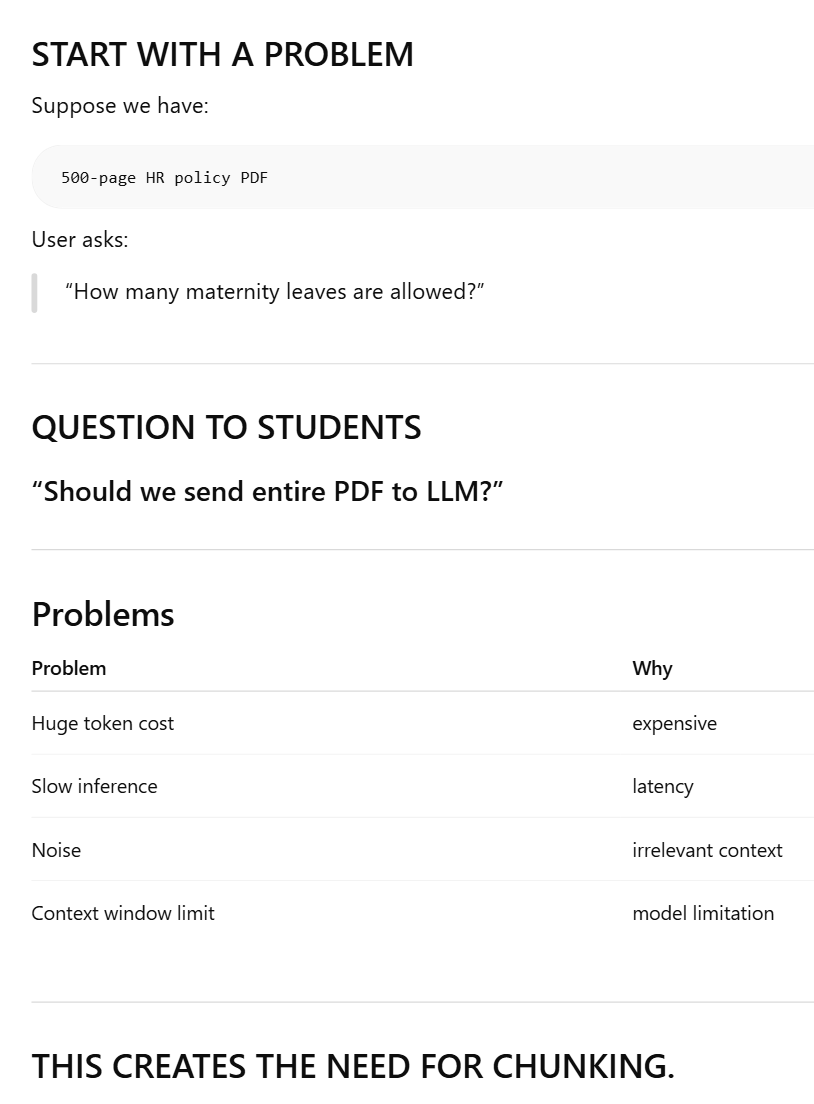

### NO CHUNKING

In [39]:
document = """
Employees receive 20 annual paid leaves.
Health insurance covers employees and dependents.
Travel reimbursement is available for business trips.
Employees can work remotely twice a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are allocated quarterly.
Performance reviews occur every six months.
Employees must submit leave requests through HR portal.
Training sessions are conducted every quarter.
Internet expenses are reimbursed for remote employees.
"""

query = "How can I apply for leave?"

# Load embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert entire document into ONE embedding
document_embedding = model.encode([document])

# Convert query into embedding
query_embedding = model.encode([query])

# Similarity check
score = cosine_similarity(
    query_embedding,
    document_embedding
)[0][0]

print(f"Similarity Score: {score:.4f}")

print("\nRetrieved Context:\n")
print(document)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Similarity Score: 0.2981

Retrieved Context:


Employees receive 20 annual paid leaves.
Health insurance covers employees and dependents.
Travel reimbursement is available for business trips.
Employees can work remotely twice a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are allocated quarterly.
Performance reviews occur every six months.
Employees must submit leave requests through HR portal.
Training sessions are conducted every quarter.
Internet expenses are reimbursed for remote employees.



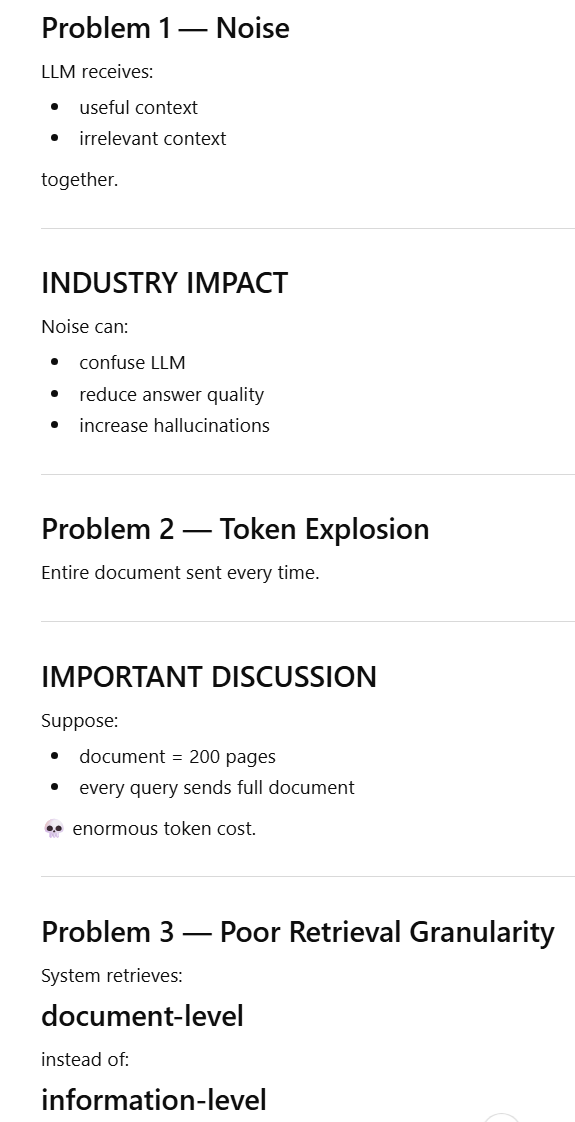

**Without chunking, retrieval becomes document retrieval instead of knowledge retrieval.**

In [40]:
# Chunking the document
chunks = text.split(".")

chunks = [chunk.strip() for chunk in chunks if chunk.strip()]

query = "How can I apply for leave?"

model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings for each chunk
chunk_embeddings = model.encode(chunks)

# Query embedding
query_embedding = model.encode([query])

# Similarity scores
scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

# Get best matching chunk
best_index = np.argmax(scores)

print("Best Retrieved Chunk:\n")
print(chunks[best_index])

print("\nAll Similarity Scores:\n")

for chunk, score in zip(chunks, scores):
    print(f"{score:.4f} --> {chunk}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Best Retrieved Chunk:

RAG is a technique used to improve LLM responses

All Similarity Scores:

0.1036 --> RAG is a technique used to improve LLM responses
0.0404 --> Embeddings convert text into vectors
-0.0666 --> Semantic search finds meaning-based matches


### LARGE CHUNK

In [105]:
text = """
Employees receive 20 annual paid leaves.
Employees must submit leave requests through the HR portal.
Health insurance covers employees and dependents.
Travel reimbursement is available for business trips.
Employees can work remotely twice a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are allocated quarterly.
Performance reviews occur every six months.
Internet expenses are reimbursed for remote employees.
Training sessions are conducted every quarter.
"""

In [106]:
query = "How can I apply for leave?"

model = SentenceTransformer('all-MiniLM-L6-v2')

# LARGE CHUNKS
chunk_size = 200

chunks = [
    text[i:i+chunk_size]
    for i in range(0, len(text), chunk_size)
]

print("\nGenerated Chunks:\n")

for idx, chunk in enumerate(chunks):
    print(f"Chunk {idx+1}:\n{chunk}\n")

chunk_embeddings = model.encode(chunks)

query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

top_index = np.argmax(scores)

print("\nBest Retrieved Chunk:\n")
print(chunks[top_index])

print("\nSimilarity Scores:\n")

for chunk, score in zip(chunks, scores):
    print(f"{score:.4f}")
    print(chunk)
    print("-"*50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Generated Chunks:

Chunk 1:

Employees receive 20 annual paid leaves.
Employees must submit leave requests through the HR portal.
Health insurance covers employees and dependents.
Travel reimbursement is available for business t

Chunk 2:
rips.
Employees can work remotely twice a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are allocated quarterly.
Performance reviews occur every six months.
Internet expenses are

Chunk 3:
 reimbursed for remote employees.
Training sessions are conducted every quarter.



Best Retrieved Chunk:


Employees receive 20 annual paid leaves.
Employees must submit leave requests through the HR portal.
Health insurance covers employees and dependents.
Travel reimbursement is available for business t

Similarity Scores:

0.4529

Employees receive 20 annual paid leaves.
Employees must submit leave requests through the HR portal.
Health insurance covers employees and dependents.
Travel reimbursement is available for business t
------------

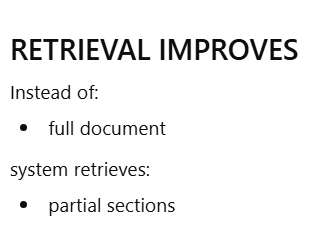

### EXTREME GRANULARITY

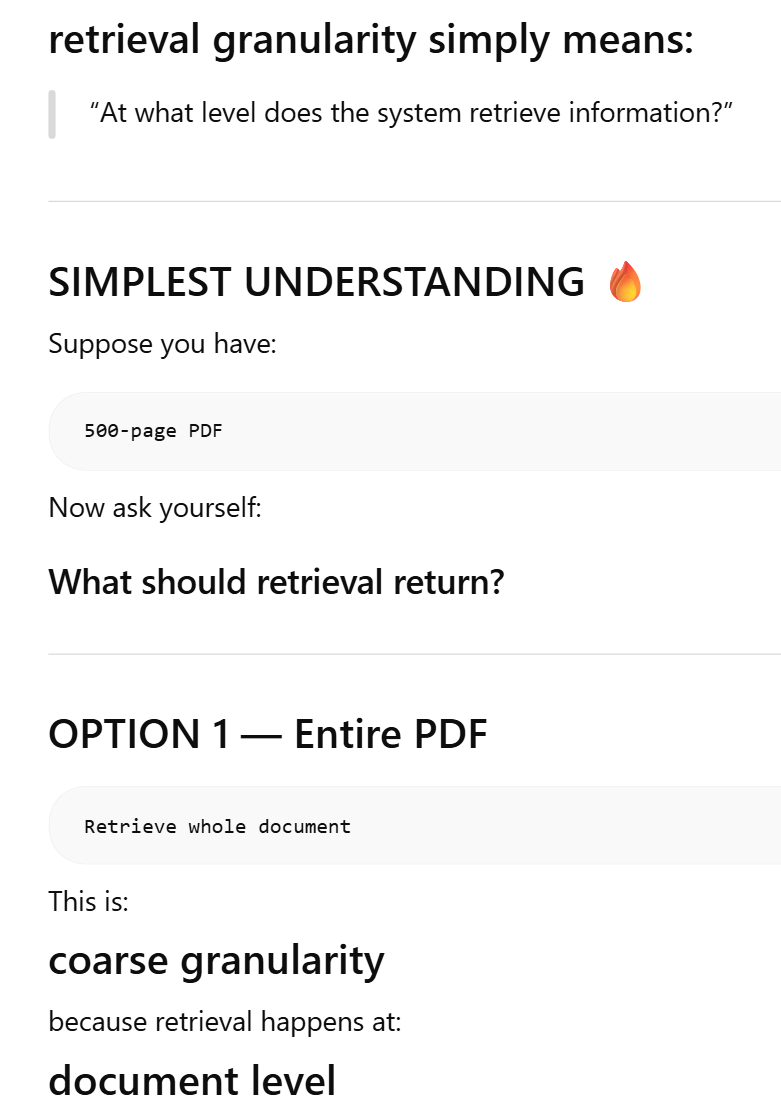

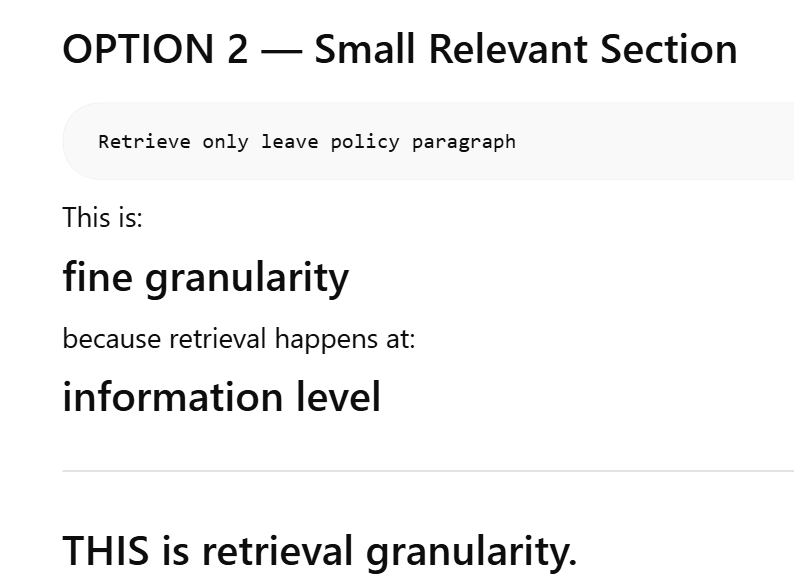

In [43]:
query = "How can I apply for leave?"

model = SentenceTransformer('all-MiniLM-L6-v2')

# VERY SMALL CHUNKS
chunk_size = 25

chunks = [
    text[i:i+chunk_size]
    for i in range(0, len(text), chunk_size)
]

print("\nGenerated Chunks:\n")

for idx, chunk in enumerate(chunks):
    print(f"Chunk {idx+1}: {chunk}")

chunk_embeddings = model.encode(chunks)

query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

top_index = np.argmax(scores)

print("\nBest Retrieved Chunk:\n")
print(chunks[top_index])

print("\nSimilarity Scores:\n")

for chunk, score in zip(chunks, scores):
    print(f"{score:.4f} --> {chunk}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Generated Chunks:

Chunk 1: 
Employees receive 20 ann
Chunk 2: ual paid leaves.
Employee
Chunk 3: s must submit leave reque
Chunk 4: sts through the HR portal
Chunk 5: .
Health insurance covers
Chunk 6:  employees and dependents
Chunk 7: .
Travel reimbursement is
Chunk 8:  available for business t
Chunk 9: rips.
Employees can work 
Chunk 10: remotely twice a week.
Of
Chunk 11: fice cafeteria serves fre
Chunk 12: e lunch on Fridays.
Parki
Chunk 13: ng spaces are allocated q
Chunk 14: uarterly.
Performance rev
Chunk 15: iews occur every six mont
Chunk 16: hs.
Internet expenses are
Chunk 17:  reimbursed for remote em
Chunk 18: ployees.
Training session
Chunk 19: s are conducted every qua
Chunk 20: rter.


Best Retrieved Chunk:

s must submit leave reque

Similarity Scores:

0.1087 --> 
Employees receive 20 ann
0.3517 --> ual paid leaves.
Employee
0.4883 --> s must submit leave reque
0.1648 --> sts through the HR portal
0.1300 --> .
Health insurance covers
0.2348 -->  employees and depend

#### OVERLAP CHUNKING

In [44]:
query = "How can I apply for leave?"

model = SentenceTransformer('all-MiniLM-L6-v2')

chunk_size = 80
chunk_overlap = 20

chunks = []

start = 0

while start < len(text):

    end = start + chunk_size

    chunk = text[start:end]

    chunks.append(chunk)

    start += chunk_size - chunk_overlap

print("\nGenerated Chunks:\n")

for idx, chunk in enumerate(chunks):
    print(f"\nChunk {idx+1}:\n{chunk}")

chunk_embeddings = model.encode(chunks)

query_embedding = model.encode([query])

scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

top_index = np.argmax(scores)

print("\nBest Retrieved Chunk:\n")
print(chunks[top_index])

print("\nSimilarity Scores:\n")

for chunk, score in zip(chunks, scores):
    print(f"{score:.4f}")
    print(chunk)
    print("-"*50)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Generated Chunks:


Chunk 1:

Employees receive 20 annual paid leaves.
Employees must submit leave requests t

Chunk 2:
mit leave requests through the HR portal.
Health insurance covers employees and 

Chunk 3:
overs employees and dependents.
Travel reimbursement is available for business t

Chunk 4:
lable for business trips.
Employees can work remotely twice a week.
Office cafet

Chunk 5:
a week.
Office cafeteria serves free lunch on Fridays.
Parking spaces are alloca

Chunk 6:
ng spaces are allocated quarterly.
Performance reviews occur every six months.
I

Chunk 7:
 every six months.
Internet expenses are reimbursed for remote employees.
Traini

Chunk 8:
te employees.
Training sessions are conducted every quarter.


Chunk 9:



Best Retrieved Chunk:


Employees receive 20 annual paid leaves.
Employees must submit leave requests t

Similarity Scores:

0.5259

Employees receive 20 annual paid leaves.
Employees must submit leave requests t
---------------------------------------------

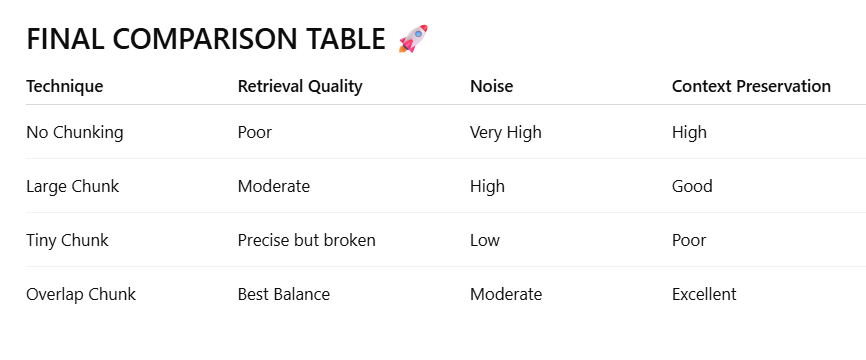

# RAG is basically:
search + ranking + context injection + generation.”

**RAG retrieves external knowledge before generating an answer.**

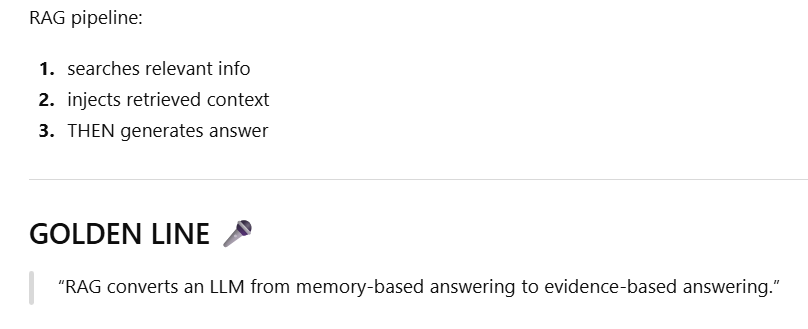

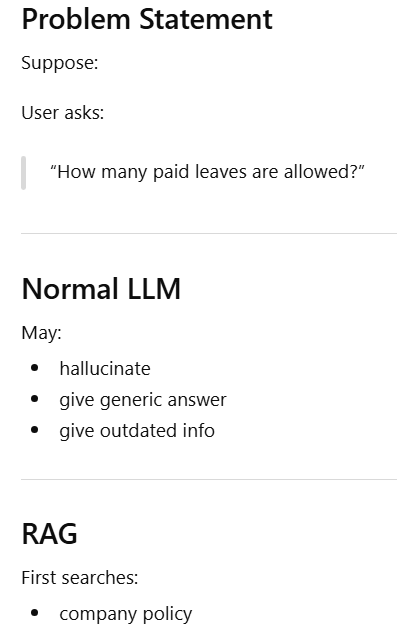

In [107]:
from sentence_transformers import SentenceTransformer # for embeddings
from sklearn.metrics.pairwise import cosine_similarity # semantic retrieval
import numpy as np # for ranking

In [108]:
documents = [
    "Employees receive 20 annual paid leaves.",
    
    "Employees must submit leave requests through the HR portal.",
    
    "Health insurance covers employees and dependents.",
    
    "Travel reimbursement is available for business trips.",
    
    "Employees can work remotely twice a week.",
    
    "Internet expenses are reimbursed for remote employees."
]

In [109]:
model = SentenceTransformer('all-MiniLM-L6-v2') # all-MiniLM-L6-v2, 'all-mpnet-base-v2',

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

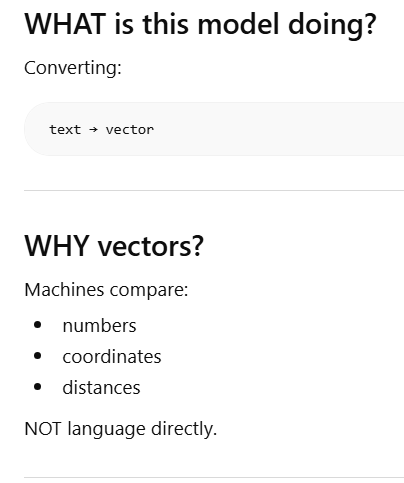

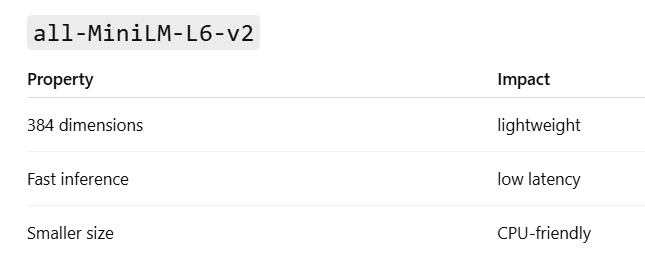

In [110]:
document_embeddings = model.encode(documents)
# coverting text into vector representation

In [121]:
query = "Give me more info about Health Insurance and travel reimburstment"

In [122]:
query_embedding = model.encode([query])

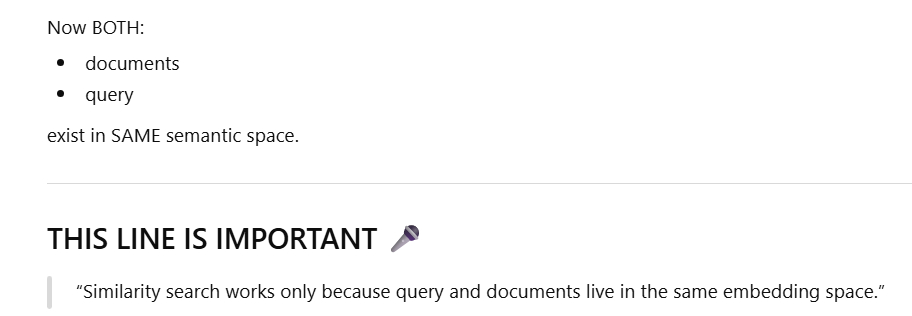

In [123]:
scores = cosine_similarity(
    query_embedding,
    document_embeddings
)[0]

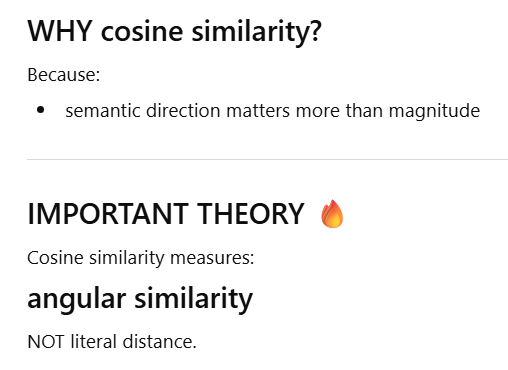

In [124]:
ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

In [125]:
top_k = 2

top_results = ranked_results[:top_k]
top_results

[('Travel reimbursement is available for business trips.',
  np.float32(0.55667555)),
 ('Health insurance covers employees and dependents.', np.float32(0.50385326)),
 ('Internet expenses are reimbursed for remote employees.',
  np.float32(0.22597995)),
 ('Employees receive 20 annual paid leaves.', np.float32(0.16169888))]

In [126]:
retrieved_context = "\n".join(
    [doc for doc, score in top_results]
)

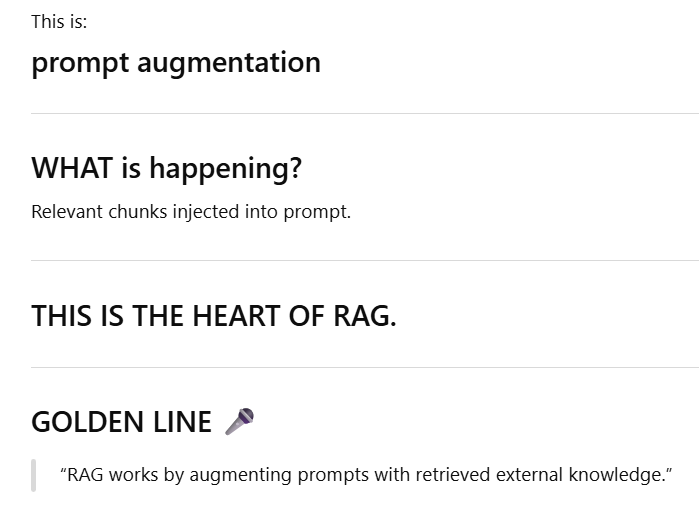

In [127]:
final_prompt = f"""
Answer the question based only on the context below.

Context:
{retrieved_context}

Question:
{query}
"""

In [128]:
print(final_prompt)


Answer the question based only on the context below.

Context:
Travel reimbursement is available for business trips.
Health insurance covers employees and dependents.
Internet expenses are reimbursed for remote employees.
Employees receive 20 annual paid leaves.

Question:
Give me more info about Health Insurance and travel reimburstment



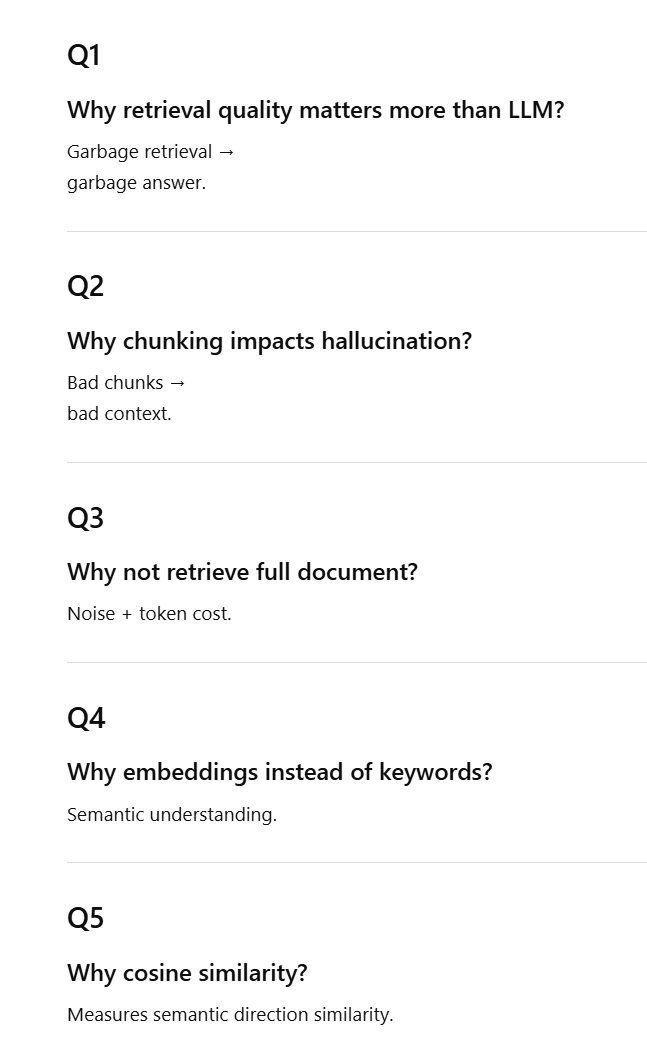

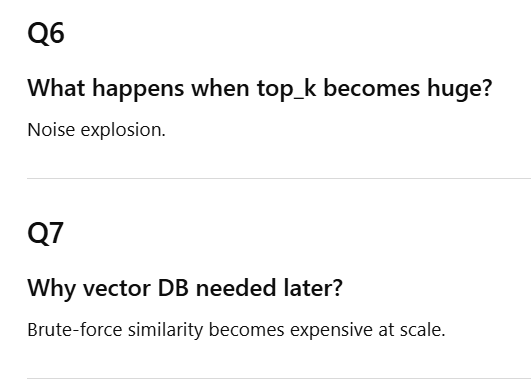

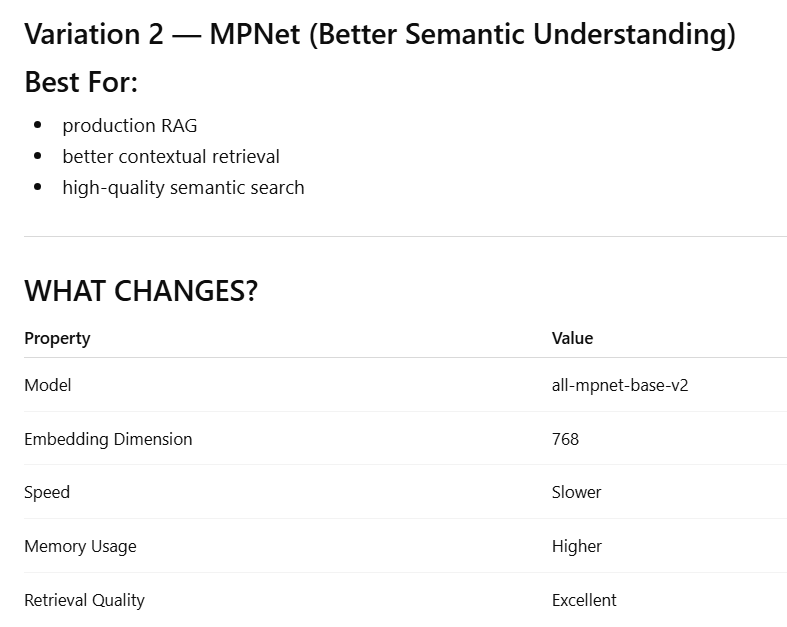

In [59]:
from sentence_transformers import SentenceTransformer

models = [
    'all-MiniLM-L6-v2',
    'all-mpnet-base-v2',
    'BAAI/bge-small-en',
    'intfloat/e5-small-v2'
]

for model_name in models:
    print(f"Downloading: {model_name}")
    SentenceTransformer(model_name)

print("All models cached successfully")

Downloading: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Downloading: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Akshay\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Akshay\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

All models cached successfully


In [60]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# DOCUMENTS
# -----------------------------

documents = [
    "Employees receive 20 annual paid leaves.",
    "Employees must submit leave requests through the HR portal.",
    "Health insurance covers employees and dependents.",
    "Travel reimbursement is available for business trips.",
    "Employees can work remotely twice a week."
]

query = "How can I apply for leave?"

# -----------------------------
# LOAD MPNet MODEL
# -----------------------------

model = SentenceTransformer(
    'all-mpnet-base-v2'
)

# -----------------------------
# CREATE EMBEDDINGS
# -----------------------------

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

# -----------------------------
# SIMILARITY SEARCH
# -----------------------------

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

# -----------------------------
# RANK RESULTS
# -----------------------------

ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

# -----------------------------
# OUTPUT
# -----------------------------

print("\nEmbedding Shape:")
print(doc_embeddings.shape)

print("\nRetrieved Results:\n")

for doc, score in ranked_results:
    print(f"{score:.4f} --> {doc}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Embedding Shape:
(5, 768)

Retrieved Results:

0.6271 --> Employees must submit leave requests through the HR portal.
0.2842 --> Employees receive 20 annual paid leaves.
0.1886 --> Travel reimbursement is available for business trips.
0.1770 --> Employees can work remotely twice a week.
0.1404 --> Health insurance covers employees and dependents.


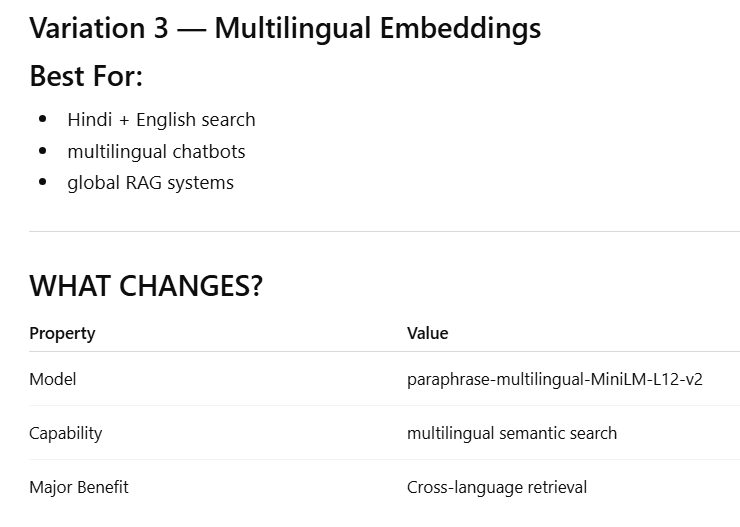

In [61]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# DOCUMENTS
# -----------------------------

documents = [
    "Employees receive 20 annual paid leaves.",
    "Employees must submit leave requests through the HR portal.",
    "Health insurance covers employees and dependents.",
    "Travel reimbursement is available for business trips.",
    "Employees can work remotely twice a week."
]

# HINDI QUERY
query = "छुट्टी के लिए apply कैसे करें?"

# -----------------------------
# LOAD MULTILINGUAL MODEL
# -----------------------------

model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

# -----------------------------
# CREATE EMBEDDINGS
# -----------------------------

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

# -----------------------------
# SIMILARITY SEARCH
# -----------------------------

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

# -----------------------------
# RANK RESULTS
# -----------------------------

ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

# -----------------------------
# OUTPUT
# -----------------------------

print("\nRetrieved Results:\n")

for doc, score in ranked_results:
    print(f"{score:.4f} --> {doc}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\Akshay\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Akshay\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Retrieved Results:

0.2249 --> Travel reimbursement is available for business trips.
0.1925 --> Employees receive 20 annual paid leaves.
0.0958 --> Employees must submit leave requests through the HR portal.
0.0706 --> Health insurance covers employees and dependents.
0.0401 --> Employees can work remotely twice a week.


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# ENGLISH DOCUMENTS
# -----------------------------

documents = [
    "Employees receive 20 annual paid leaves.",
    
    "Employees must submit leave requests through the HR portal.",
    
    "Health insurance covers employees and dependents.",
    
    "Travel reimbursement is available for business trips.",
    
    "Employees can work remotely twice a week."
]

# -----------------------------
# MARATHI QUERY
# -----------------------------

query = "रजेचा अर्ज कसा करायचा?"

# Meaning:
# "How to apply for leave?"

# -----------------------------
# LOAD MULTILINGUAL MODEL
# -----------------------------

model = SentenceTransformer(
    'paraphrase-multilingual-MiniLM-L12-v2'
)

# -----------------------------
# CREATE EMBEDDINGS
# -----------------------------

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

# -----------------------------
# SIMILARITY SEARCH
# -----------------------------

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

# -----------------------------
# RANK RESULTS
# -----------------------------

ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

# -----------------------------
# OUTPUT
# -----------------------------

print("\nQuery:")
print(query)

print("\nRetrieved Results:\n")

for doc, score in ranked_results:
    print(f"{score:.4f} --> {doc}")

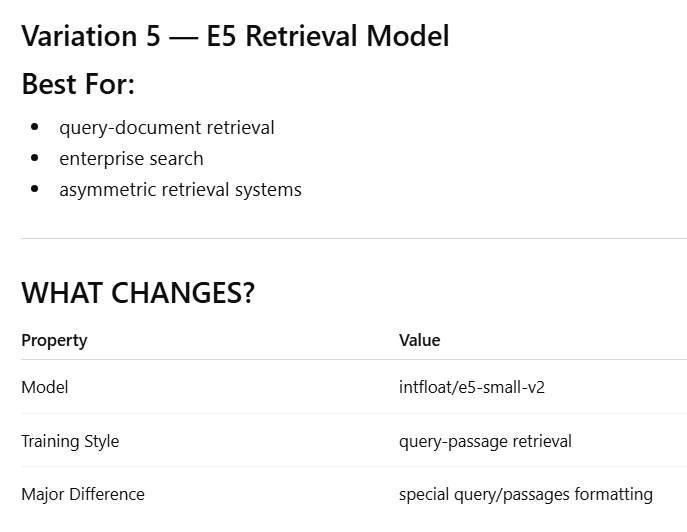

In [62]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# DOCUMENTS
# -----------------------------

documents = [
    "passage: Employees receive 20 annual paid leaves.",
    
    "passage: Employees must submit leave requests through the HR portal.",
    
    "passage: Health insurance covers employees and dependents.",
    
    "passage: Travel reimbursement is available for business trips.",
    
    "passage: Employees can work remotely twice a week."
]

query = "query: How can I apply for leave?"

# -----------------------------
# LOAD E5 MODEL
# -----------------------------

model = SentenceTransformer(
    'intfloat/e5-small-v2'
)

# -----------------------------
# CREATE EMBEDDINGS
# -----------------------------

doc_embeddings = model.encode(documents)

query_embedding = model.encode([query])

# -----------------------------
# SIMILARITY SEARCH
# -----------------------------

scores = cosine_similarity(
    query_embedding,
    doc_embeddings
)[0]

# -----------------------------
# RANK RESULTS
# -----------------------------

ranked_results = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

# -----------------------------
# OUTPUT
# -----------------------------

print("\nRetrieved Results:\n")

for doc, score in ranked_results:
    print(f"{score:.4f} --> {doc}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Retrieved Results:

0.8660 --> passage: Employees must submit leave requests through the HR portal.
0.7894 --> passage: Health insurance covers employees and dependents.
0.7742 --> passage: Travel reimbursement is available for business trips.
0.7709 --> passage: Employees receive 20 annual paid leaves.
0.7605 --> passage: Employees can work remotely twice a week.


# TASK

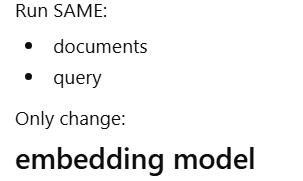

# 1. Which model ranked best?
# 2. Which model was fastest?
# 3. Which model handled Hindi?
# 4. Which model produced better semantic understanding?
# 5. Which model should production systems use?